# TP: Analyse de Sentiment avec SVM

## Objectifs

Dans ce TP, nous allons:

1. Chercher le meilleur modèle SVM (type + hyperparamètres) pour classifier des critiques de films en **positive** ou **negative**.
2. Comparer ce meilleur SVM à d'autres techniques de classification (Régression Logistique, Arbre de décision, KNN).
3. Présenter les résultats dans un tableau comparatif avec des métriques pertinentes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1) Chargement des données

In [2]:
with open("reviews.txt", "r", encoding="utf-8", errors="ignore") as f:
    reviews = [line.strip() for line in f.readlines()]

with open("labels.txt", "r", encoding="utf-8", errors="ignore") as f:
    labels_text = [line.strip().lower() for line in f.readlines()]

print(f"Nombre de critiques: {len(reviews)}")
print(f"Nombre de labels: {len(labels_text)}")

assert len(reviews) == len(labels_text), "Le nombre de critiques et de labels doit être identique."

label_mapping = {"negative": 0, "positive": 1}
y = np.array([label_mapping[label] for label in labels_text])
X = np.array(reviews)

df = pd.DataFrame({"review": X, "label_text": labels_text, "label": y})
df.head()

Nombre de critiques: 5000
Nombre de labels: 5000


,review,label_text,label
0,bromwell high is a cartoon comedy . it ran at ...,positive,1
1,story of a man who has unnatural feelings for ...,negative,0
2,homelessness or houselessness as george carli...,positive,1
3,airport starts as a brand new luxury pla...,negative,0
4,brilliant over acting by lesley ann warren . ...,positive,1


Distribution des classes:
label_text
positive    2500
negative    2500
Name: count, dtype: int64


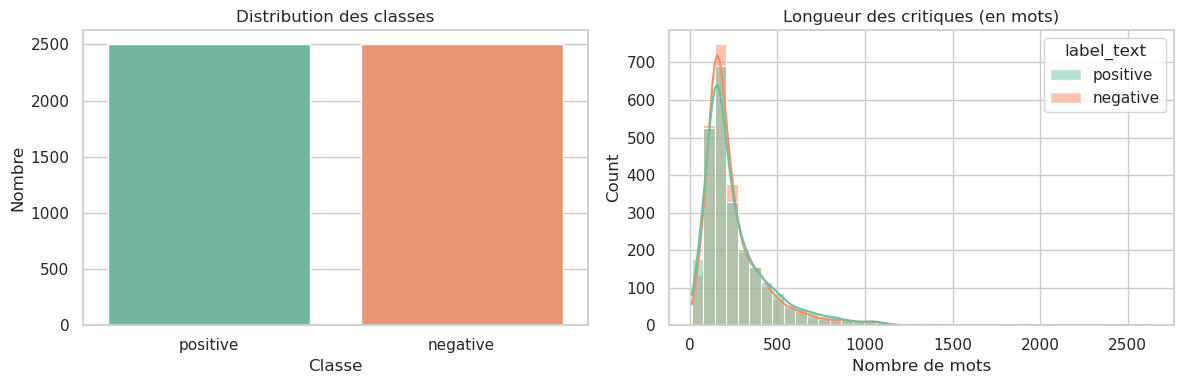

In [3]:
df["longueur"] = df["review"].str.split().str.len()

print("Distribution des classes:")
print(df["label_text"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="label_text", ax=axes[0], palette="Set2")
axes[0].set_title("Distribution des classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre")

sns.histplot(data=df, x="longueur", hue="label_text", bins=40, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Longueur des critiques (en mots)")
axes[1].set_xlabel("Nombre de mots")

plt.tight_layout()
plt.show()

## 2) Séparation entraînement / test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Taille train: {X_train.shape[0]}")
print(f"Taille test : {X_test.shape[0]}")

Taille train: 4000
Taille test : 1000


## 3) Recherche du meilleur SVM (type + hyperparamètres)

On utilise un pipeline TF-IDF + classificateur SVM, puis une validation croisée via `GridSearchCV`.

In [5]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC()),
])

param_grid_svm = [
    {
        "clf": [LinearSVC(random_state=RANDOM_STATE, max_iter=3000)],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2, 5],
        "tfidf__max_features": [10000, 20000],
        "clf__C": [0.5, 1.0, 2.0],
    },
    {
        "clf": [SVC(kernel="linear", random_state=RANDOM_STATE)],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2, 5],
        "tfidf__max_features": [10000],
        "clf__C": [0.5, 1.0, 2.0],
    },
]

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_svm.fit(X_train, y_train)

print("Meilleurs paramètres SVM:")
print(grid_svm.best_params_)
print(f"Meilleur score CV (F1): {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Meilleurs paramètres SVM:
{'clf': LinearSVC(max_iter=3000, random_state=42), 'clf__C': 2.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Meilleur score CV (F1): 0.8975


## 4) Évaluation du meilleur modèle SVM sur le jeu de test

Rapport de classification (Meilleur SVM):
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91       500
    positive       0.91      0.91      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



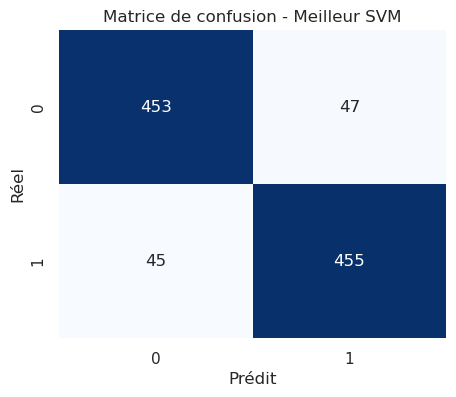

In [6]:
y_pred_svm = best_svm.predict(X_test)

print("Rapport de classification (Meilleur SVM):")
print(classification_report(y_test, y_pred_svm, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de confusion - Meilleur SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

## 5) Comparaison SVM vs autres techniques

On compare les modèles suivants:

- SVM (meilleur trouvé)
- Régression Logistique
- Arbre de décision
- KNN

In [7]:
models = {
    "SVM (meilleur)": best_svm,
    "Régression logistique": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "Arbre de décision": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 1), min_df=2, max_features=15000)),
        ("clf", DecisionTreeClassifier(max_depth=40, min_samples_split=10, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 1), min_df=2, max_features=15000)),
        ("clf", KNeighborsClassifier(n_neighbors=7, metric="cosine")),
    ]),
}

resultats = []

for nom, modele in models.items():
    if nom != "SVM (meilleur)":
        modele.fit(X_train, y_train)

    y_pred = modele.predict(X_test)

    resultats.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    })

df_resultats = pd.DataFrame(resultats).sort_values(by="F1-score", ascending=False)
df_resultats.reset_index(drop=True, inplace=True)
df_resultats

,Modèle,Accuracy,Precision,Recall,F1-score
0,SVM (meilleur),0.908,0.906375,0.910,0.908184
1,Régression logistique,0.889,0.874759,0.908,0.891070
2,KNN,0.853,0.820327,0.904,0.860133
3,Arbre de décision,0.679,0.673114,0.696,0.684366


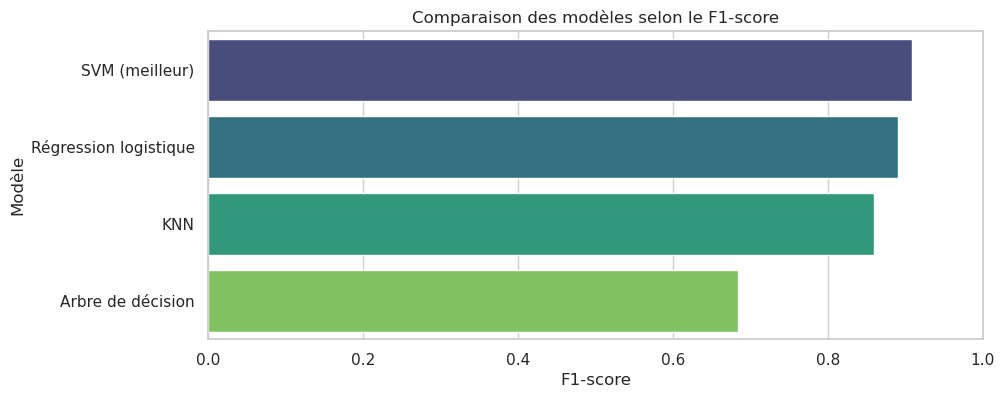

Exception ignored in: <function ResourceTracker.__del__ at 0x716cf65832e0>
Traceback (most recent call last):
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7bf7b85972e0>
Traceback (most recent call last):
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/mar1shell/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function 

In [ ]:
plt.figure(figsize=(10, 4))
ordre = df_resultats.sort_values("F1-score", ascending=False)
sns.barplot(data=ordre, x="F1-score", y="Modèle", palette="viridis")
plt.title("Comparaison des modèles selon le F1-score")
plt.xlim(0, 1)
plt.show()

## 6) Conclusion

- Le modèle SVM sélectionné par validation croisée fournit le meilleur compromis entre précision et rappel (mesuré ici par le F1-score).
- Pour ce problème de text mining, les modèles linéaires (SVM, Régression Logistique) sont généralement plus adaptés que les modèles basés sur la distance brute (KNN) ou des arbres simples.
- Le tableau comparatif permet de justifier objectivement le choix du modèle final.